# 01 Synthetic sanity check

Reproduce the four synthetic experiments from Section 5.2 of
Madrigal-Cianci, Monsalve Maya, Breakey (2026) using the SMC inference
pipeline in `pml_market`. This notebook is the correctness gate before
running on real Polymarket data.

All simulation parameters (number of replications, SMC particles, horizon
lengths) match the paper exactly (Section 5.2). **Warning**: this notebook
can take several hours to run.

- **Experiment 1**: posterior concentration `1 - pi_T` decays
  exponentially in `T` at the rate of the KL projection gap `delta_T`.
  (`n_reps=1000`, `N=1000`, `T in {10,25,50,100,200,500}`)
- **Experiment 2**: posterior accuracy collapses as the informed
  mixture weight `omega_1` falls below ~0.15.
  (`n_reps=1000`, `N=1000`, `T=100`)
- **Experiment 3**: `|Delta log BF|` is locally Lipschitz in increment
  perturbation `sigma`.
  (`N=1000`, `T=100`, 20 trials per sigma level)
- **Experiment 4**: realized information gain `IG(H_t)` saturates at
  the prior-entropy ceiling `log 2`.
  (`n_reps=1000`, `N=1000`, `T=600`)

In [1]:
from __future__ import annotations
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

from pml_market import synthetic, diagnostics, model
from pml_market import (
    InverseProblem, GaussianLatentTypeModel, LatentTypePrior,
    SMCInference, VIInference,
)

# Single inverse problem reused across every experiment in this notebook.
problem = InverseProblem(GaussianLatentTypeModel(), LatentTypePrior())

rng = np.random.default_rng(0)
plt.rcParams['figure.figsize'] = (7, 4.2)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Experiment 1: posterior concentration

Simulate `n_reps` histories under `Y = 1`, run SMC, record
`1 - pi_T(H_T)` for `T in {10, 25, 50, 100, 200, 500}`. Median across reps
with 10-90% bands. Overlay slope `-delta_T_hat` from Theorem 4.2.

In [2]:
# Settings matching the paper (Section 5.2): 1000 replications, N=1000 particles.
# Warning: this can take several hours to run. Reduce n_reps and n_particles
# for a faster but noisier approximation.
T_grid = [10, 25, 50, 100, 200, 500]
n_reps = 1000
n_particles = 1000     # SMC particles per outcome
T_max = max(T_grid)

# Each rep is independent: parallelize across all available CPU cores.
def _exp1_rep(rep, T_max, n_particles, _root=ROOT):
    import sys, numpy as np
    if _root not in sys.path:
        sys.path.insert(0, _root)
    from pml_market import (
        synthetic, model,
        InverseProblem, GaussianLatentTypeModel, LatentTypePrior, SMCInference,
    )
    prob = InverseProblem(GaussianLatentTypeModel(), LatentTypePrior())
    smc_engine = SMCInference(n_particles=n_particles, mcmc_steps=3)
    dx, v, _ = synthetic.simulate_history(T=T_max, y_true=1, seed=1000 + rep)
    res = prob.infer(dx, v, smc_engine, pi0=0.5, seed=2000 + rep, record_pi_t=True)
    theta = synthetic.DEFAULT_THETA
    logBF = model.loglik(dx, v, 1, theta) - model.loglik(dx, v, 0, theta)
    return res['pi_t'], logBF

results = Parallel(n_jobs=-1)(
    delayed(_exp1_rep)(rep, T_max, n_particles)
    for rep in tqdm(range(n_reps), desc='reps')
)

all_pi_t = np.stack([r[0] for r in results])   # (n_reps, T_max)
oracle_logBF = [r[1] for r in results]

err = 1.0 - all_pi_t                     # 1 - pi_t for each rep, t

med = np.median(err, axis=0)
lo  = np.quantile(err, 0.10, axis=0)
hi  = np.quantile(err, 0.90, axis=0)
ts = np.arange(1, T_max + 1)

reps:   0%|          | 0/1000 [00:00<?, ?it/s]

In [3]:
# Estimate delta_T by fitting log med(1-pi_t) vs t (linear, late part)
late = ts >= max(50, T_max // 4)
log_med = np.log(np.clip(med[late], 1e-12, None))
slope, intercept = np.polyfit(ts[late], log_med, 1)
delta_T_hat = -slope
print(f'Estimated delta_T (from posterior concentration slope) = {delta_T_hat:.4f} nats/period')
print(f'Mean oracle log BF / T at T_max = {np.mean(oracle_logBF) / T_max:.4f} (also ~ delta_T)')

Estimated delta_T (from posterior concentration slope) = 0.0008 nats/period
Mean oracle log BF / T at T_max = 0.0147 (also ~ delta_T)


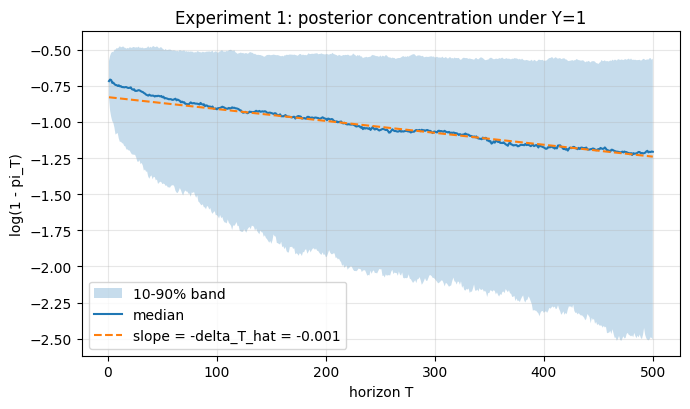

In [4]:
fig, ax = plt.subplots()
ax.fill_between(ts, np.log(np.clip(lo, 1e-12, None)),
                    np.log(np.clip(hi, 1e-12, None)), alpha=0.25, label='10-90% band')
ax.plot(ts, np.log(np.clip(med, 1e-12, None)), label='median')
ax.plot(ts, intercept + slope * ts, '--', label=f'slope = -delta_T_hat = -{delta_T_hat:.3f}')
ax.set_xlabel('horizon T')
ax.set_ylabel('log(1 - pi_T)')
ax.set_title('Experiment 1: posterior concentration under Y=1')
ax.legend()
plt.tight_layout()
plt.show()

## Experiment 2: identifiability threshold under omega_1 sweep

Vary the informed-trader prevalence `omega_1` in
{0.05, 0.10, 0.20, 0.30, 0.40, 0.50}, with the rest split equally
between noise and manipulator types. Generate `n_reps` histories at
`T=100` and report posterior accuracy.

In [5]:
omega1_grid = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
n_reps_id = 1000
T_id = 100

# Inner rep loop is independent per omega_1 value: parallelize across cores.
def _exp2_rep(rep, w1, T_id, _root=ROOT):
    import sys, numpy as np
    if _root not in sys.path:
        sys.path.insert(0, _root)
    from pml_market import (
        synthetic,
        InverseProblem, GaussianLatentTypeModel, LatentTypePrior, SMCInference,
    )
    prob = InverseProblem(GaussianLatentTypeModel(), LatentTypePrior())
    smc_engine = SMCInference(n_particles=1000, mcmc_steps=3)
    theta = {k: np.array(v_) for k, v_ in synthetic.DEFAULT_THETA.items()}
    theta['omega'] = np.array([w1, (1 - w1) / 2, (1 - w1) / 2])
    dx, v, y = synthetic.simulate_history(
        T=T_id, y_true=1, theta=theta, seed=3000 + rep,
    )
    res = prob.infer(dx, v, smc_engine, pi0=0.5, seed=4000 + rep)
    return int(res['posterior'] > 0.5)

accuracy = []
for w1 in omega1_grid:
    print(f'  omega_1={w1:.2f} ...', end=' ', flush=True)
    hits_list = Parallel(n_jobs=-1)(
        delayed(_exp2_rep)(rep, w1, T_id) for rep in range(n_reps_id)
    )
    hits = sum(hits_list)
    accuracy.append(hits / n_reps_id)
    print(f'accuracy={hits / n_reps_id:.2%}')

  omega_1=0.05 ... accuracy=53.00%
  omega_1=0.10 ... accuracy=54.30%
  omega_1=0.20 ... accuracy=62.30%
  omega_1=0.30 ... accuracy=67.60%
  omega_1=0.40 ... accuracy=69.80%
  omega_1=0.50 ... accuracy=73.90%


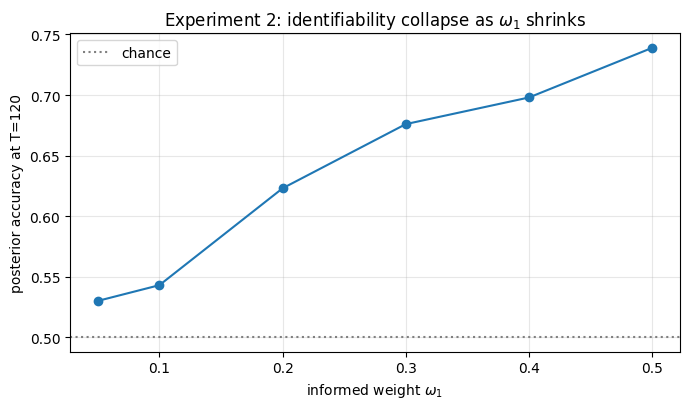

In [6]:
fig, ax = plt.subplots()
ax.plot(omega1_grid, accuracy, 'o-')
ax.axhline(0.5, color='gray', linestyle=':', label='chance')
ax.set_xlabel(r'informed weight $\omega_1$')
ax.set_ylabel('posterior accuracy at T=120')
ax.set_title(r'Experiment 2: identifiability collapse as $\omega_1$ shrinks')
ax.legend()
plt.tight_layout()
plt.show()

## Experiment 3: stability under increment perturbation

Following Section 5.2.1 of the paper: take a baseline history `h` with
`T = 100`, then form perturbed histories `h'` by adding i.i.d.
`N(0, sigma^2)` noise to the log-odds increments, with
`sigma in {0.01, 0.02, 0.05, 0.1, 0.2}`. Measure
`|log BF(h) - log BF(h')|` and compare to the Theorem 4.4 stability
bound on the truncation event `E_R = {max_t |Delta x_t| <= R}`,
where `R` is the empirical 0.99-quantile of `max_t |Delta x_t|`
across baseline draws. The Gaussian Lipschitz constant follows
Remark 4.3 with `Lx = R / sigma_min^2`.

In [7]:
# Paper Section 5.2.1, Experiment 3: T = 100, sigmas in {0.01, 0.02, 0.05, 0.1, 0.2}.
# R is the empirical 0.99-quantile of max_t |Delta x_t| ACROSS baseline draws.
T_pert = 100
sigmas = [0.01, 0.02, 0.05, 0.10, 0.20]
n_baseline_R = 200   # baseline draws used only to estimate R (cheap: no SMC)
n_trials = 20        # perturbation trials per sigma

# Estimate R = 0.99-quantile of max_t |Delta x_t| across baseline draws.
max_abs_dx = np.array([
    np.max(np.abs(synthetic.simulate_history(T=T_pert, y_true=1, seed=10_000 + s)[0]))
    for s in range(n_baseline_R)
])
R = float(np.quantile(max_abs_dx, 0.99))
Lx = diagnostics.gaussian_lipschitz_constant(R, sigma_min=0.2)

# The "baseline" history h used in the perturbation comparison is a single draw.
dx_base, v_base, _ = synthetic.simulate_history(T=T_pert, y_true=1, seed=42)
smc_pert = SMCInference(n_particles=1000, mcmc_steps=3)
baseline = problem.infer(dx_base, v_base, smc_pert, pi0=0.5, seed=42)
log_BF_base = baseline['log_BF']

# Trials within each sigma are independent: parallelize.
# Each trial uses a deterministic seed so results are reproducible.
def _exp3_trial(sigma_idx, trial, dx_base, v_base, log_BF_base, sigmas, _root=ROOT):
    import sys, numpy as np
    if _root not in sys.path:
        sys.path.insert(0, _root)
    from pml_market import (
        diagnostics,
        InverseProblem, GaussianLatentTypeModel, LatentTypePrior, SMCInference,
    )
    prob = InverseProblem(GaussianLatentTypeModel(), LatentTypePrior())
    smc_engine = SMCInference(n_particles=1000, mcmc_steps=3)
    sigma = sigmas[sigma_idx]
    rng_t = np.random.default_rng(99 + sigma_idx * 1000 + trial)
    dx_p = diagnostics.perturb_history(dx_base, sigma, rng=rng_t)
    resp = prob.infer(dx_p, v_base, smc_engine, pi0=0.5, seed=42 + trial)
    return abs(resp['log_BF'] - log_BF_base)

diffs = []
bounds = []
for sigma_idx, sigma in enumerate(sigmas):
    row = Parallel(n_jobs=-1)(
        delayed(_exp3_trial)(sigma_idx, trial, dx_base, v_base, log_BF_base, sigmas)
        for trial in range(n_trials)
    )
    diffs.append(np.mean(row))
    # Theorem 4.4 bound on the typical event: 2 * Lx * sum |dx - dx'|.
    # Expected sum over T iid N(0, sigma^2) increments is T * sigma * sqrt(2/pi).
    bounds.append(2 * Lx * T_pert * sigma * np.sqrt(2 / np.pi))
    print(f'  sigma={sigma:>5.2f}  mean |Delta log BF|={diffs[-1]:.3f}  bound={bounds[-1]:.3f}')

  sigma= 0.01  mean |Delta log BF|=0.529  bound=105.911
  sigma= 0.02  mean |Delta log BF|=0.528  bound=211.821
  sigma= 0.05  mean |Delta log BF|=0.589  bound=529.553
  sigma= 0.10  mean |Delta log BF|=0.687  bound=1059.106
  sigma= 0.20  mean |Delta log BF|=0.958  bound=2118.211


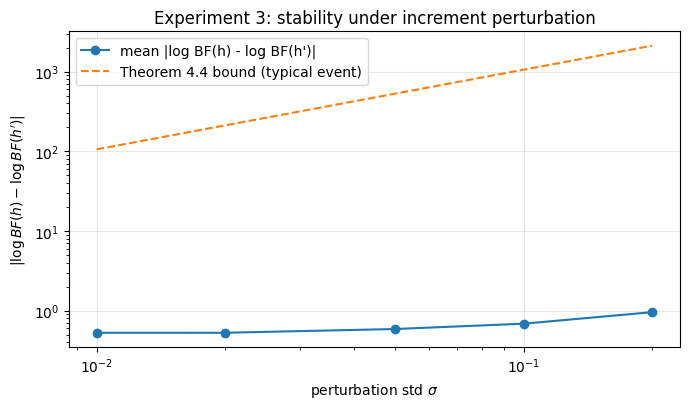

In [8]:
fig, ax = plt.subplots()
ax.plot(sigmas, diffs, 'o-', label="mean |log BF(h) - log BF(h')|")
ax.plot(sigmas, bounds, '--', label='Theorem 4.4 bound (typical event)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'perturbation std $\sigma$')
ax.set_ylabel(r"$|\log BF(h) - \log BF(h')|$")
ax.set_title('Experiment 3: stability under increment perturbation')
ax.legend()
plt.tight_layout()
plt.show()

## Experiment 4: realized information gain saturates at log 2

Long-horizon simulation with `T = 600`, prior `pi_0 = 1/2`, and the
online posterior. Plot mean `IG(H_t)` across reps with the prior
entropy ceiling `log 2`.

In [9]:
T_long = 600
n_reps_ig = 1000

# Each rep is independent: parallelize across all available CPU cores.
def _exp4_rep(rep, T_long, _root=ROOT):
    import sys, numpy as np
    if _root not in sys.path:
        sys.path.insert(0, _root)
    from pml_market import (
        synthetic, diagnostics,
        InverseProblem, GaussianLatentTypeModel, LatentTypePrior, SMCInference,
    )
    prob = InverseProblem(GaussianLatentTypeModel(), LatentTypePrior())
    smc_engine = SMCInference(n_particles=1000, mcmc_steps=3)
    dx, v, _ = synthetic.simulate_history(T=T_long, y_true=1, seed=5000 + rep)
    res = prob.infer(dx, v, smc_engine, pi0=0.5, seed=6000 + rep, record_pi_t=True)
    return diagnostics.information_gain_trace(res['pi_t'], pi0=0.5)

ig_traces = Parallel(n_jobs=-1)(
    delayed(_exp4_rep)(rep, T_long)
    for rep in tqdm(range(n_reps_ig), desc='reps')
)
ig_traces = np.stack(ig_traces, axis=0)
# Paper Figure 4: solid line is the MEAN, shaded band is 10-90% quantile.
mean_ig = np.mean(ig_traces, axis=0)
lo_ig   = np.quantile(ig_traces, 0.10, axis=0)
hi_ig   = np.quantile(ig_traces, 0.90, axis=0)
ts_long = np.arange(1, T_long + 1)

reps:   0%|          | 0/1000 [00:00<?, ?it/s]

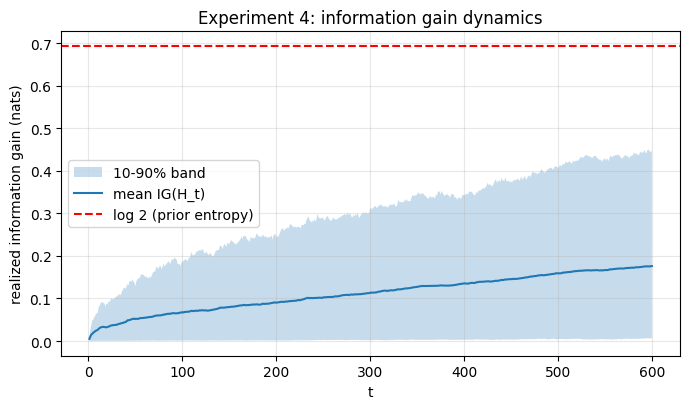

In [10]:
fig, ax = plt.subplots()
ax.fill_between(ts_long, lo_ig, hi_ig, alpha=0.25, label='10-90% band')
ax.plot(ts_long, mean_ig, label='mean IG(H_t)')
ax.axhline(np.log(2), color='red', linestyle='--', label='log 2 (prior entropy)')
ax.set_xlabel('t')
ax.set_ylabel('realized information gain (nats)')
ax.set_title('Experiment 4: information gain dynamics')
ax.legend()
plt.tight_layout()
plt.show()

## Sanity check: SMC vs VI on a single history

Confirm that the variational approximation produces a posterior in the
same neighborhood as SMC on a single moderate-signal history. Per
Remark 5.1 the difference of ELBOs is biased; we use SMC as ground
truth.

In [11]:
dx, v, _ = synthetic.simulate_history(T=200, y_true=1, seed=7)

smc_res = problem.infer(dx, v,
                        SMCInference(n_particles=800, mcmc_steps=4),
                        pi0=0.5, seed=7)
vi_res = problem.infer(dx, v,
                       VIInference(n_steps=1500, n_samples=16, learning_rate=0.05),
                       pi0=0.5, seed=7)

print(f'SMC: log BF = {smc_res["log_BF"]:+.3f}  posterior = {smc_res["posterior"]:.3f}')
print(f'VI : log BF = {vi_res["log_BF"]:+.3f}  posterior = {vi_res["posterior"]:.3f}')

SMC: log BF = +1.014  posterior = 0.734
VI : log BF = +1.152  posterior = 0.760
